# Task 2: Credit Risk Prediction

## Objective
The objective of this project is to predict whether a loan applicant is likely to default on a loan using machine learning techniques.

## Dataset
Loan Prediction Dataset

## Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn
- Scikit-learn

## Skills Demonstrated
- Data Cleaning
- Handling Missing Values
- Exploratory Data Analysis (EDA)
- Data Visualization
- Machine Learning Classification
- Model Evaluation

## Step 1: Import Required Libraries

The necessary libraries are imported for data manipulation, visualization, and machine learning.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

## Step 2: Load the Dataset

The dataset is loaded into a Pandas DataFrame for analysis and preprocessing.

In [3]:
loan = pd.read_excel('train.xlsx')
loan.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Step 3: Dataset Exploration

The structure of the dataset is examined to understand the available features and records.

In [4]:
loan.shape

(614, 13)

In [5]:
loan.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

In [6]:
loan.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), object(1), str(7)
memory usage: 62.5+ KB


In [7]:
loan.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Step 4: Handling Missing Values

Missing values can negatively affect model performance. Therefore, missing values are identified and handled appropriately.

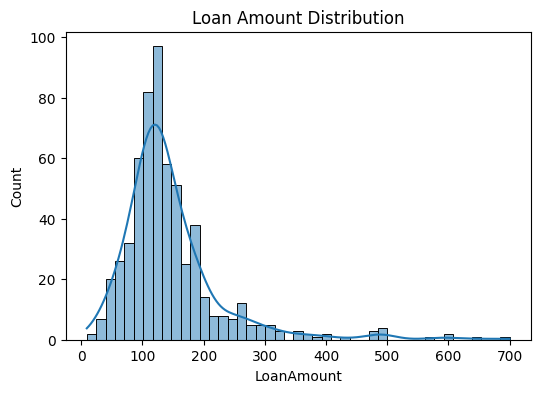

In [11]:
plt.figure(figsize=(6,4))
sns.histplot(loan['LoanAmount'], kde=True)
plt.title("Loan Amount Distribution")
plt.show()

In [8]:
loan.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [17]:
loan['Gender'] = loan['Gender'].fillna('Male')
loan['Married'] = loan['Married'].fillna('Yes')
loan['Dependents'] = loan['Dependents'].fillna('0')
loan['Self_Employed'] = loan['Self_Employed'].fillna('No')

loan['LoanAmount'] = loan['LoanAmount'].fillna(
    loan['LoanAmount'].median()
)

loan['Loan_Amount_Term'] = loan['Loan_Amount_Term'].fillna(
    loan['Loan_Amount_Term'].median()
)

loan['Credit_History'] = loan['Credit_History'].fillna(1)

In [18]:
loan.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

## Step 5: Exploratory Data Analysis (EDA)

Visualizations are created to understand important features in the dataset.

### Loan Amount Distribution

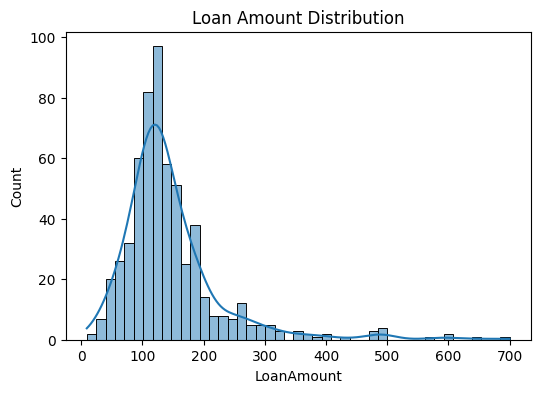

In [19]:
plt.figure(figsize=(6,4))
sns.histplot(loan['LoanAmount'], kde=True)
plt.title('Loan Amount Distribution')
plt.show()

### Education and Loan Approval Status

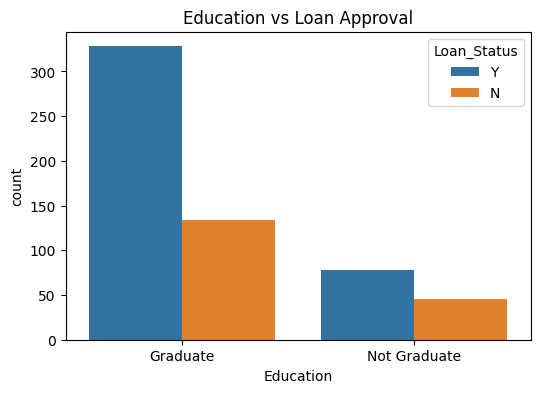

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(data=loan, x='Education', hue='Loan_Status')
plt.title('Education vs Loan Approval')
plt.show()

### Applicant Income and Loan Status

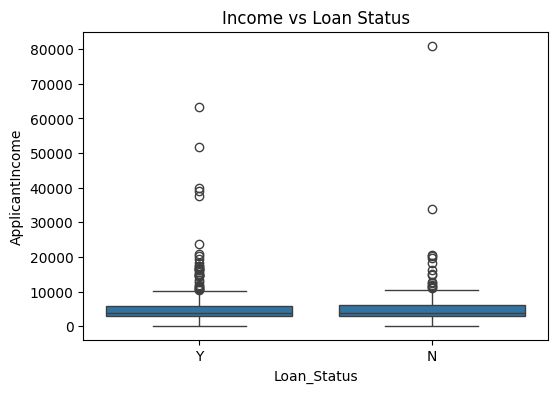

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(data=loan, x='Loan_Status', y='ApplicantIncome')
plt.title('Income vs Loan Status')
plt.show()

## Observations

- Most loan amounts fall within a moderate range.
- Education level appears to influence loan approval outcomes.
- Applicants with higher income generally show better approval rates.
- Credit history is expected to be an important factor in prediction.

## Step 6: Data Preparation

Categorical variables are converted into numerical values for machine learning.

In [22]:
loan = loan.drop('Loan_ID', axis=1)

In [23]:
categorical_columns = [
    'Gender',
    'Married',
    'Dependents',
    'Education',
    'Self_Employed',
    'Property_Area',
    'Loan_Status'
]

le = LabelEncoder()

for col in categorical_columns:
    loan[col] = le.fit_transform(loan[col].astype(str))

## Step 7: Train-Test Split

The dataset is divided into training and testing sets.

In [24]:
X = loan.drop('Loan_Status', axis=1)
y = loan['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## Step 8: Model Training

A Logistic Regression model is trained to predict loan approval status.

In [25]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

C:\Users\Silicon computers\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Step 9: Model Evaluation

The model is evaluated using Accuracy Score and Confusion Matrix.

In [26]:
y_pred = model.predict(X_test)

In [27]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8305084745762712


In [28]:
print(confusion_matrix(y_test, y_pred))

[[14 19]
 [ 1 84]]


## Conclusion

The loan prediction dataset was successfully cleaned and analyzed. Missing values were handled, important features were visualized, and a Logistic Regression model was trained. The model's performance was evaluated using accuracy and a confusion matrix, demonstrating how machine learning can be used to support credit risk prediction.